# 🏠 Análise do Mercado de Aluguéis de Imóveis em São Paulo

## 🎯 Objetivo

Este projeto tem como objetivo analisar um dataset de imóveis para aluguel em São Paulo, buscando identificar quais características dos imóveis estão mais relacionadas ao valor do aluguel.

### 🔎 Perguntas de pesquisa

1. 📐 A área do imóvel influencia o valor do aluguel?
2. 🛏️ O número de quartos influencia o preço?
3. 📍 A localização influencia o valor do aluguel?
4. 🚗 Imóveis com garagem apresentam aluguéis maiores?
5. 💰 Quais características apresentam maior relação com o valor do aluguel?

### 🧹 Etapas da análise

1. 📥 Carregamento dos dados
2. 🔍 Exploração da estrutura
3. 🧹 Limpeza dos dados
4. 📊 Análise exploratória
5. 📈 Visualizações
6. 🔗 Análise de correlações
7. 💡 Identificação de insights
8. 🏆 Conclusões e recomendações

## Importando Bibliotecas

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## Importando Arquivo Kangle

In [61]:
import pandas as pd

url = 'https://raw.githubusercontent.com/maisasq123/lia1_2026_2/refs/heads/main/Entregas%20-%20Ma%C3%ADsa%20Queiroz/Analise_Alugueis/data/data.csv'

imoveis = pd.read_csv(url)

print("🏠 Dataset de imóveis carregado com sucesso!")
print(f"📏 Dimensões: {imoveis.shape}")
print(f"📋 Colunas: {list(imoveis.columns)}")

print("\n🔍 Primeiras 5 linhas:")
imoveis.head()

🏠 Dataset de imóveis carregado com sucesso!
📏 Dimensões: (11657, 8)
📋 Colunas: ['address', 'district', 'area', 'bedrooms', 'garage', 'type', 'rent', 'total']

🔍 Primeiras 5 linhas:


,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654


In [62]:
print("🔍 EXPLORAÇÃO DA ESTRUTURA DOS DADOS")

# Informações gerais
print("\n📋 Informações das colunas:")
#  .info é uma função do Pandas usada para obter informações estruturais do DataFrame.
imoveis.info()

# Valores ausentes
print("\n🧹 Valores ausentes:")
# .sum() conta quantos valores ausentes existem em cada coluna
dados_ausentes = imoveis.isnull().sum()
print(dados_ausentes[dados_ausentes > 0])

# Valores duplicados
print(f"\n🔄 Linhas duplicadas: {imoveis.duplicated().sum()}")

# Estatísticas das variáveis numéricas
print("\n📊 Estatísticas descritivas:")
# display organiza em uma tabela, describe pega esses dados estatísticos
display(imoveis.describe())

🔍 EXPLORAÇÃO DA ESTRUTURA DOS DADOS

📋 Informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11657 entries, 0 to 11656
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   address   11657 non-null  object
 1   district  11657 non-null  object
 2   area      11657 non-null  int64 
 3   bedrooms  11657 non-null  int64 
 4   garage    11657 non-null  int64 
 5   type      11657 non-null  object
 6   rent      11657 non-null  int64 
 7   total     11657 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 728.7+ KB

🧹 Valores ausentes:
Series([], dtype: int64)

🔄 Linhas duplicadas: 0

📊 Estatísticas descritivas:


,area,bedrooms,garage,rent,total
count,11657.000000,11657.000000,11657.000000,11657.000000,11657.000000
mean,84.655658,1.966286,1.060393,3250.814789,4080.030625
std,74.020536,0.931313,1.132349,2650.711557,3352.480274
min,0.000000,0.000000,0.000000,500.000000,509.000000
25%,40.000000,1.000000,0.000000,1590.000000,1996.000000
50%,60.000000,2.000000,1.000000,2415.000000,3057.000000
75%,96.000000,3.000000,2.000000,3800.000000,4774.000000
max,580.000000,6.000000,6.000000,25000.000000,28700.000000


## Analisar quais dados precisam de limpeza

In [63]:
print("🔎 INVESTIGANDO POSSÍVEIS INCONSISTÊNCIAS")

# Tipos de imóveis
print("\n🏠 Tipos de imóveis:")
# .value_counts() conta quantas vezes cada valor aparece.
print(imoveis['type'].value_counts())

# Imóveis com área igual ou menor que zero
print("\n📐 Imóveis com área menor ou igual a zero:")
print(imoveis[imoveis['area'] <= 0])

# Valores de aluguel menores ou iguais a zero
print("\n💰 Imóveis com aluguel menor ou igual a zero:")
print(imoveis[imoveis['rent'] <= 0])

# Valores totais menores que o aluguel
print("\n🧾 Casos em que o valor total é menor que o aluguel:")
print(imoveis[imoveis['total'] < imoveis['rent']])

# Bairros mais frequentes
print("\n📍 15 bairros com mais imóveis:")
print(imoveis['district'].value_counts().head(15))

🔎 INVESTIGANDO POSSÍVEIS INCONSISTÊNCIAS

🏠 Tipos de imóveis:
type
Apartamento           7194
Casa                  2841
Studio e kitnet       1381
Casa em condomínio     241
Name: count, dtype: int64

📐 Imóveis com área menor ou igual a zero:
                    address                district  area  bedrooms  garage  \
2983           Rua Relíquia  Jardim das Laranjeiras     0         2       1   
7085  Rua Edmundo de Amicis                 Morumbi     0         3       2   

             type  rent  total  
2983  Apartamento  1600   2569  
7085         Casa  3200   3351  

💰 Imóveis com aluguel menor ou igual a zero:
Empty DataFrame
Columns: [address, district, area, bedrooms, garage, type, rent, total]
Index: []

🧾 Casos em que o valor total é menor que o aluguel:
Empty DataFrame
Columns: [address, district, area, bedrooms, garage, type, rent, total]
Index: []

📍 15 bairros com mais imóveis:
district
Bela Vista         352
Vila Mariana       232
Jardim Paulista    220
Centro        

## 🧹 Limpeza dos Dados

A análise inicial mostrou que o dataset não possui valores ausentes nem registros duplicados. Entretanto, foram identificados dois imóveis com área igual a 0 m², uma informação inconsistente para a análise do preço por área.

Como não é possível determinar a área correta desses imóveis a partir dos dados disponíveis, esses dois registros serão removidos para evitar distorções nas análises que utilizam a área do imóvel.

In [64]:
print("🧹 REALIZANDO LIMPEZA DOS DADOS\n")

# Quantidade de registros antes da limpeza
linhas_antes = len(imoveis)

# Removendo imóveis com área igual ou menor que zero
imoveis = imoveis[imoveis['area'] > 0].copy()

# Quantidade de registros removidos
linhas_removidas = linhas_antes - len(imoveis)

print(f"📊 Registros antes da limpeza: {linhas_antes}")
print(f"🗑️ Registros removidos: {linhas_removidas}")
print(f"📊 Registros após a limpeza: {len(imoveis)}")

# Verificação final
print(f"\n🔍 Valores ausentes restantes: {imoveis.isnull().sum().sum()}")
print(f"🔄 Linhas duplicadas restantes: {imoveis.duplicated().sum()}")
print(f"📐 Imóveis com área inválida: {(imoveis['area'] <= 0).sum()}")

print("\n✅ Dataset pronto para análise!")

🧹 REALIZANDO LIMPEZA DOS DADOS

📊 Registros antes da limpeza: 11657
🗑️ Registros removidos: 2
📊 Registros após a limpeza: 11655

🔍 Valores ausentes restantes: 0
🔄 Linhas duplicadas restantes: 0
📐 Imóveis com área inválida: 0

✅ Dataset pronto para análise!


## 📊 Visão Geral dos Imóveis

Após a limpeza dos dados, vamos analisar algumas estatísticas gerais do mercado de aluguéis antes de investigar as perguntas de pesquisa.

In [65]:
print("📊 VISÃO GERAL DO MERCADO DE ALUGUÉIS\n")

print(f"🏠 Total de imóveis analisados: {len(imoveis):,}")
print(f"💰 Aluguel médio: R$ {imoveis['rent'].mean():,.2f}")
print(f"💰 Aluguel mediano: R$ {imoveis['rent'].median():,.2f}")
print(f"📐 Área média: {imoveis['area'].mean():.1f} m²")
print(f"🛏️ Média de quartos: {imoveis['bedrooms'].mean():.1f}")
print(f"🚗 Média de vagas: {imoveis['garage'].mean():.1f}")

print("\n💰 Valores de aluguel:")
print(f"   Menor aluguel: R$ {imoveis['rent'].min():,.2f}")
print(f"   Maior aluguel: R$ {imoveis['rent'].max():,.2f}")

print("\n📐 Área dos imóveis:")
print(f"   Menor área: {imoveis['area'].min()} m²")
print(f"   Maior área: {imoveis['area'].max()} m²")

📊 VISÃO GERAL DO MERCADO DE ALUGUÉIS

🏠 Total de imóveis analisados: 11,655
💰 Aluguel médio: R$ 3,250.96
💰 Aluguel mediano: R$ 2,415.00
📐 Área média: 84.7 m²
🛏️ Média de quartos: 2.0
🚗 Média de vagas: 1.1

💰 Valores de aluguel:
   Menor aluguel: R$ 500.00
   Maior aluguel: R$ 25,000.00

📐 Área dos imóveis:
   Menor área: 1 m²
   Maior área: 580 m²


## 📊 Análise Exploratória com Gráficos

Vamos utilizar visualizações e análises estatísticas para investigar as principais características relacionadas ao valor do aluguel.

### 📐 Pergunta 1: A área do imóvel influencia o valor do aluguel?

> **Hipótese:** imóveis com maior área tendem a apresentar valores de aluguel mais elevados.

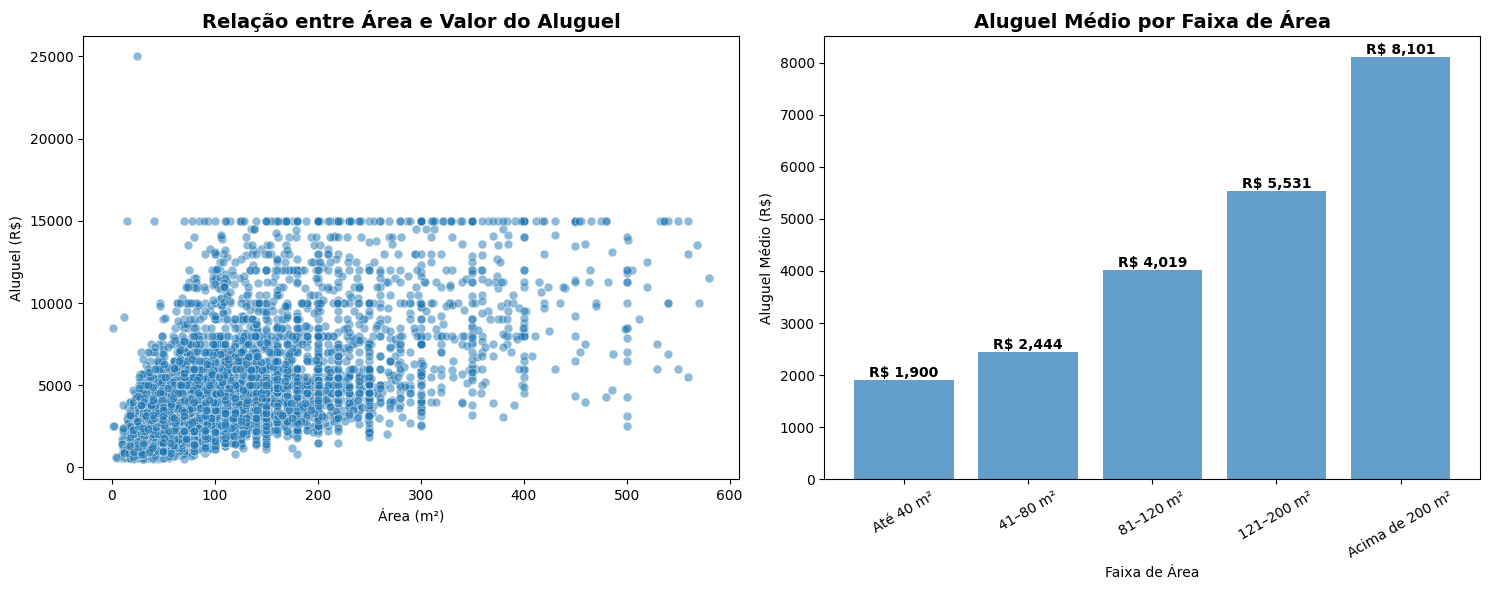

In [66]:
# 📐 Pergunta 1: Área x Valor do Aluguel

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Relação entre área e aluguel
sns.scatterplot(
    x='area',
    y='rent',
    data=imoveis,
    alpha=0.5,
    s=40,
    ax=ax1
)

ax1.set_title('Relação entre Área e Valor do Aluguel',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Área (m²)')
ax1.set_ylabel('Aluguel (R$)')

# Gráfico 2: Aluguel médio por faixa de área
imoveis['faixa_area'] = pd.cut(
    imoveis['area'],
    bins=[0, 40, 80, 120, 200, float('inf')],
    labels=['Até 40 m²', '41–80 m²', '81–120 m²',
            '121–200 m²', 'Acima de 200 m²']
)
# Agrupe os imóveis por faixa de área e calcule o aluguel médio de cada grupo
aluguel_por_area = imoveis.groupby(
    'faixa_area',
    observed=True
)['rent'].mean()

ax2.bar(
    range(len(aluguel_por_area)),
    aluguel_por_area.values,
    alpha=0.7
)

ax2.set_title('Aluguel Médio por Faixa de Área',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Faixa de Área')
ax2.set_ylabel('Aluguel Médio (R$)')
ax2.set_xticks(range(len(aluguel_por_area)))
ax2.set_xticklabels(aluguel_por_area.index, rotation=30)

# Valores nas barras
for i, valor in enumerate(aluguel_por_area.values):
    ax2.text(
        i,
        valor,
        f'R$ {valor:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [67]:
# 📊 Análise estatística

correlacao_area = imoveis['area'].corr(imoveis['rent'])

print("📊 Análise Estatística - Área e Aluguel:")
print("=" * 50)

print(f"📐 Área média: {imoveis['area'].mean():.1f} m²")
print(f"💰 Aluguel médio: R$ {imoveis['rent'].mean():,.2f}")
print(f"📈 Correlação entre área e aluguel: {correlacao_area:.3f}")

print("\n💰 Aluguel médio por faixa de área:")
for faixa, valor in aluguel_por_area.items():
    print(f"✓ {faixa}: R$ {valor:,.2f}")

📊 Análise Estatística - Área e Aluguel:
📐 Área média: 84.7 m²
💰 Aluguel médio: R$ 3,250.96
📈 Correlação entre área e aluguel: 0.667

💰 Aluguel médio por faixa de área:
✓ Até 40 m²: R$ 1,899.53
✓ 41–80 m²: R$ 2,444.48
✓ 81–120 m²: R$ 4,018.62
✓ 121–200 m²: R$ 5,530.67
✓ Acima de 200 m²: R$ 8,100.58


### 🔍 Insights

- 📐 Existe uma correlação positiva de **0,667** entre a área do imóvel e o valor do aluguel.
- 💰 O aluguel médio aumenta progressivamente conforme aumenta a área do imóvel.
- 🏠 Imóveis com mais de 200 m² apresentam o maior aluguel médio, de aproximadamente **R$ 8.101**.

- 📊 Apesar da relação positiva, existe grande dispersão entre área e preço, indicando que outros fatores também influenciam o valor do aluguel.
- ⚠️ Foi identificado um possível valor atípico, com aluguel de **R$ 25.000** para um imóvel de área relativamente pequena, que deverá ser investigado posteriormente.

### 📋 Conclusão

A hipótese inicial é sustentada pelos dados: imóveis maiores tendem a apresentar valores de aluguel mais elevados. Entretanto, a correlação de **0,667** indica que a área não é o único fator associado ao preço. Características como localização, tipo de imóvel, número de quartos e vagas de garagem também podem contribuir para explicar essa diferença.

### 🛏️ Pergunta 2: O número de quartos está relacionado ao valor do aluguel?

> **Hipótese:** imóveis com maior número de quartos tendem a apresentar valores de aluguel mais elevados.

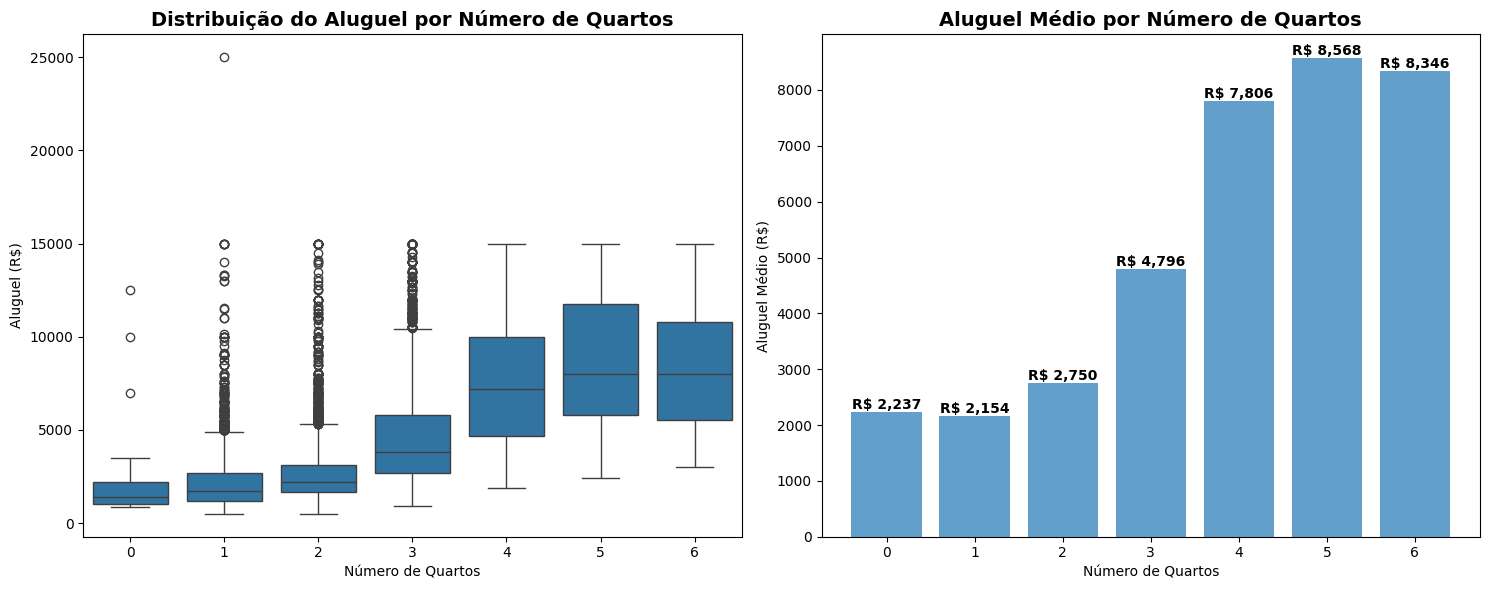

In [68]:
# 🛏️ Pergunta 2: Quartos x Valor do Aluguel

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribuição dos aluguéis por número de quartos
sns.boxplot(
    x='bedrooms',
    y='rent',
    data=imoveis,
    ax=ax1
)

ax1.set_title(
    'Distribuição do Aluguel por Número de Quartos',
    fontsize=14,
    fontweight='bold'
)
ax1.set_xlabel('Número de Quartos')
ax1.set_ylabel('Aluguel (R$)')

# Gráfico 2: Aluguel médio por número de quartos
aluguel_por_quarto = imoveis.groupby('bedrooms')['rent'].mean()

ax2.bar(
    aluguel_por_quarto.index.astype(str),
    aluguel_por_quarto.values,
    alpha=0.7
)

ax2.set_title(
    'Aluguel Médio por Número de Quartos',
    fontsize=14,
    fontweight='bold'
)
ax2.set_xlabel('Número de Quartos')
ax2.set_ylabel('Aluguel Médio (R$)')

# Adicionando os valores nas barras
for i, valor in enumerate(aluguel_por_quarto.values):
    ax2.text(
        i,
        valor,
        f'R$ {valor:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [69]:
# 📊 Análise estatística

correlacao_quartos = imoveis['bedrooms'].corr(imoveis['rent'])

print("📊 Análise Estatística - Quartos e Aluguel:")
print("=" * 50)

print(f"🛏️ Média de quartos: {imoveis['bedrooms'].mean():.2f}")
print(f"💰 Aluguel médio geral: R$ {imoveis['rent'].mean():,.2f}")
print(f"📈 Correlação entre quartos e aluguel: {correlacao_quartos:.3f}")

print("\n💰 Aluguel médio por número de quartos:")

for quartos, valor in aluguel_por_quarto.items():
    quantidade = (imoveis['bedrooms'] == quartos).sum()
    print(
        f"✓ {quartos} quarto(s): "
        f"R$ {valor:,.2f} "
        f"({quantidade} imóveis)"
    )

📊 Análise Estatística - Quartos e Aluguel:
🛏️ Média de quartos: 1.97
💰 Aluguel médio geral: R$ 3,250.96
📈 Correlação entre quartos e aluguel: 0.531

💰 Aluguel médio por número de quartos:
✓ 0 quarto(s): R$ 2,236.78 (37 imóveis)
✓ 1 quarto(s): R$ 2,153.96 (4193 imóveis)
✓ 2 quarto(s): R$ 2,749.54 (4346 imóveis)
✓ 3 quarto(s): R$ 4,795.90 (2422 imóveis)
✓ 4 quarto(s): R$ 7,806.27 (543 imóveis)
✓ 5 quarto(s): R$ 8,568.25 (91 imóveis)
✓ 6 quarto(s): R$ 8,346.30 (23 imóveis)


### 🔍 Insights

- 🛏️ Existe uma correlação positiva de **0,531** entre o número de quartos e o valor do aluguel.
- 💰 O aluguel médio tende a aumentar conforme aumenta o número de quartos.
- 🏠 Imóveis com 3 quartos apresentam aluguel médio de aproximadamente **R\$ 4.796**, enquanto imóveis com 4 quartos apresentam média de aproximadamente **R\$ 7.806**.
- 📊 A maior concentração de imóveis está entre 1 e 3 quartos, que representam a maior parte dos registros analisados.
- ⚠️ As categorias com 5 e 6 quartos possuem poucos imóveis, portanto seus valores médios devem ser interpretados com cautela.
- 🔎 A presença de muitos valores atípicos indica que outros fatores, como área e localização, também podem estar associados ao preço.

### 📋 Conclusão

A hipótese é parcialmente confirmada pelos dados. Existe uma relação positiva moderada entre o número de quartos e o valor do aluguel, com correlação de **0,531**. De modo geral, imóveis com mais quartos apresentam valores de aluguel maiores. Entretanto, a dispersão dos preços e a presença de valores atípicos mostram que o número de quartos não é suficiente para explicar sozinho o valor do aluguel.

### 📍 Pergunta 3: A localização influencia o valor do aluguel?

> **Hipótese:** imóveis localizados em diferentes bairros apresentam valores médios de aluguel significativamente diferentes.

Para tornar a comparação mais confiável, serão considerados apenas bairros com pelo menos 30 imóveis no dataset.

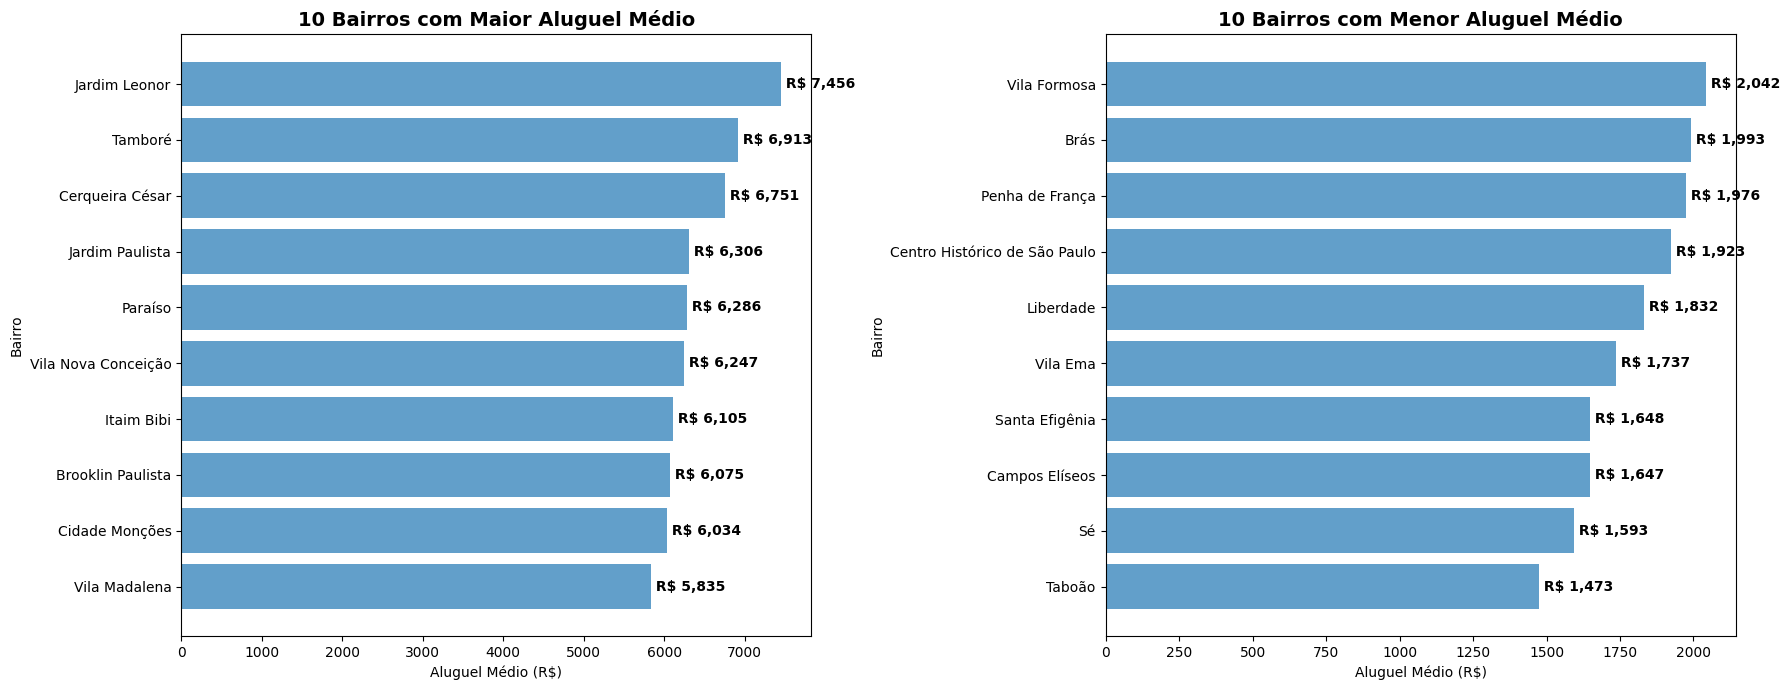

In [70]:
# 📍 Pergunta 3: Localização x Valor do Aluguel

# Quantidade de imóveis por bairro
quantidade_bairro = imoveis['district'].value_counts()

# Selecionando apenas bairros com pelo menos 30 imóveis
bairros_validos = quantidade_bairro[quantidade_bairro >= 30].index

imoveis_bairros = imoveis[
    imoveis['district'].isin(bairros_validos)
].copy()

# Aluguel médio por bairro
aluguel_por_bairro = (
    imoveis_bairros
    .groupby('district')['rent']
    .mean()
    .sort_values(ascending=False)
)

# Selecionando os 10 bairros com maior aluguel médio
top_10_bairros = aluguel_por_bairro.head(10)

# Selecionando os 10 bairros com menor aluguel médio
menores_10_bairros = aluguel_por_bairro.tail(10).sort_values()

# Criando os gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: 10 bairros com maior aluguel médio
ax1.barh(
    top_10_bairros.index[::-1],
    top_10_bairros.values[::-1],
    alpha=0.7
)

ax1.set_title(
    '10 Bairros com Maior Aluguel Médio',
    fontsize=14,
    fontweight='bold'
)
ax1.set_xlabel('Aluguel Médio (R$)')
ax1.set_ylabel('Bairro')

# Valores nas barras
for i, valor in enumerate(top_10_bairros.values[::-1]):
    ax1.text(
        valor,
        i,
        f' R$ {valor:,.0f}',
        va='center',
        fontweight='bold'
    )

# Gráfico 2: 10 bairros com menor aluguel médio
ax2.barh(
    menores_10_bairros.index,
    menores_10_bairros.values,
    alpha=0.7
)

ax2.set_title(
    '10 Bairros com Menor Aluguel Médio',
    fontsize=14,
    fontweight='bold'
)
ax2.set_xlabel('Aluguel Médio (R$)')
ax2.set_ylabel('Bairro')

# Valores nas barras
for i, valor in enumerate(menores_10_bairros.values):
    ax2.text(
        valor,
        i,
        f' R$ {valor:,.0f}',
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [71]:
# 📊 Análise estatística - Localização

print("📊 Análise Estatística - Localização e Aluguel:")
print("=" * 55)

print(f"📍 Total de bairros no dataset: {imoveis['district'].nunique()}")
print(f"📍 Bairros com pelo menos 30 imóveis: {len(bairros_validos)}")
print(f"🏠 Imóveis considerados na análise: {len(imoveis_bairros):,}")

print("\n💰 10 bairros com maior aluguel médio:")

for bairro, valor in top_10_bairros.items():
    quantidade = (imoveis_bairros['district'] == bairro).sum()
    print(
        f"✓ {bairro}: R$ {valor:,.2f} "
        f"({quantidade} imóveis)"
    )

print("\n💰 10 bairros com menor aluguel médio:")

for bairro, valor in menores_10_bairros.items():
    quantidade = (imoveis_bairros['district'] == bairro).sum()
    print(
        f"✓ {bairro}: R$ {valor:,.2f} "
        f"({quantidade} imóveis)"
    )

📊 Análise Estatística - Localização e Aluguel:
📍 Total de bairros no dataset: 1199
📍 Bairros com pelo menos 30 imóveis: 78
🏠 Imóveis considerados na análise: 5,871

💰 10 bairros com maior aluguel médio:
✓ Jardim Leonor: R$ 7,455.74 (38 imóveis)
✓ Tamboré: R$ 6,912.68 (34 imóveis)
✓ Cerqueira César: R$ 6,750.66 (140 imóveis)
✓ Jardim Paulista: R$ 6,305.96 (220 imóveis)
✓ Paraíso: R$ 6,285.56 (89 imóveis)
✓ Vila Nova Conceição: R$ 6,246.77 (77 imóveis)
✓ Itaim Bibi: R$ 6,105.29 (51 imóveis)
✓ Brooklin Paulista: R$ 6,074.67 (46 imóveis)
✓ Cidade Monções: R$ 6,034.27 (49 imóveis)
✓ Vila Madalena: R$ 5,835.31 (32 imóveis)

💰 10 bairros com menor aluguel médio:
✓ Taboão: R$ 1,473.14 (49 imóveis)
✓ Sé: R$ 1,593.30 (63 imóveis)
✓ Campos Elíseos: R$ 1,646.79 (117 imóveis)
✓ Santa Efigênia: R$ 1,647.53 (43 imóveis)
✓ Vila Ema: R$ 1,736.86 (36 imóveis)
✓ Liberdade: R$ 1,831.74 (141 imóveis)
✓ Centro Histórico de São Paulo: R$ 1,923.47 (73 imóveis)
✓ Penha de França: R$ 1,975.83 (40 imóveis)
✓ Brá

In [72]:
# 🔎 Investigando o bairro Taboão

taboao = imoveis[
    imoveis['district'].str.contains('Taboão', case=False, na=False)
]

print("📍 Registros encontrados para Taboão:")
print(f"Quantidade de imóveis: {len(taboao)}")

display(taboao[['address', 'district', 'area', 'bedrooms', 'type', 'rent', 'total']])

📍 Registros encontrados para Taboão:
Quantidade de imóveis: 53


,address,district,area,bedrooms,type,rent,total
208,Rua Armando Pinelli,Taboão,54,2,Apartamento,1100,1743
1111,Rua Tasuke Uematsu,Taboão,150,3,Casa,2580,2761
1179,Avenida do Taboão,Taboão,58,2,Apartamento,1150,1658
1258,Rua Ameixeiras,Taboão,28,1,Casa,550,604
1343,Rua Panamericana,Taboão,85,2,Casa,1450,1568
1448,Rua Venezuela,Taboão,49,1,Apartamento,970,1230
1544,Rua Jorge Cândido Marin,Taboão,52,2,Apartamento,2600,3203
1570,Rua Chile,Taboão,24,1,Casa,830,1031
1768,Rua Milton Teixeira de Siqueira,Taboão,140,3,Casa,1390,1512
2129,Rua Eugênia S Vitale,Taboão,53,2,Apartamento,2000,2782


### 🔍 Insights

- 📍 O valor médio do aluguel apresenta diferenças expressivas entre os bairros analisados.
- 💰 O Jardim Leonor apresentou o maior aluguel médio, de aproximadamente R\$ 7.456.
- 💵 Taboão apresentou o menor aluguel médio entre os bairros analisados, de aproximadamente R\$ 1.473.
- 📊 A diferença entre o maior e o menor aluguel médio foi de aproximadamente R\$ 5.983.
- 🏙️ Bairros como Jardim Paulista, Paraíso, Vila Nova Conceição, Itaim Bibi e Vila Madalena aparecem entre aqueles com maiores valores médios.
- 🔎 Os resultados sugerem que a localização está associada ao valor do aluguel, mas outras características dos imóveis também podem explicar parte dessas diferenças.

### 📋 Conclusão

A hipótese é sustentada pelos dados: existem diferenças significativas nos valores médios de aluguel entre os bairros. O resultado indica que a localização está associada ao preço dos imóveis, com alguns bairros apresentando valores médios muito superiores a outros. Entretanto, essa análise não permite afirmar que a localização, isoladamente, determina o preço, pois características como área, número de quartos e tipo de imóvel também podem variar entre os bairros.

## 📍 Contextualização dos Bairros

Os resultados da análise mostram uma diferença expressiva entre os valores médios de aluguel dos bairros. Para interpretar esse comportamento, é importante considerar as características urbanas e socioeconômicas das regiões onde esses imóveis estão localizados.

Os bairros com maiores valores médios de aluguel estão concentrados, em grande parte, em regiões tradicionalmente valorizadas de São Paulo e da Região Metropolitana, enquanto diversos bairros com menores valores médios estão localizados em áreas centrais populares ou em regiões mais acessíveis.

### 🏙️ Regiões com maiores valores de aluguel

Bairros como Jardim Paulista, Cerqueira César, Vila Nova Conceição, Itaim Bibi e Vila Madalena apresentam características associadas à valorização imobiliária, como localização estratégica, ampla oferta de serviços, comércio, restaurantes, cultura, transporte e proximidade de importantes áreas empresariais.

O Jardim Paulista integra a região dos Jardins e é considerado um bairro de alto padrão, com um dos mercados imobiliários mais valorizados de São Paulo. Sua proximidade com a Avenida Paulista e o Parque Ibirapuera contribui para sua atratividade residencial.

Cerqueira César também possui localização estratégica próxima à Avenida Paulista e aos Jardins, com forte concentração de comércio, serviços, cultura e imóveis de padrão elevado.

A Vila Nova Conceição é conhecida pelo alto padrão residencial, pela proximidade com o Parque Ibirapuera e pela concentração de serviços e estabelecimentos de maior padrão.

O Itaim Bibi combina uso residencial de alto padrão com uma forte concentração de atividades empresariais e serviços, o que contribui para a elevada demanda imobiliária.

Já a Vila Madalena apresenta um perfil diferente: além da valorização imobiliária, destaca-se pela vida cultural, restaurantes, bares, galerias e pelo turismo. A região também vem passando por substituição de imóveis residenciais horizontais por empreendimentos verticais de alto padrão.

### 🏢 Regiões com menores valores de aluguel

Entre os bairros com menores valores médios aparecem regiões como Brás, Sé, Santa Efigênia, Campos Elíseos, Liberdade, Vila Ema e Taboão.

É importante destacar que menor aluguel não significa necessariamente uma região "pobre". Esses bairros possuem características urbanas bastante diferentes entre si.

O Brás, por exemplo, é uma importante região comercial da cidade, com forte atividade varejista e grande fluxo de pessoas. A região também possui ampla conexão com o transporte público.

A Sé e outros bairros da região central apresentam grande concentração de comércio, serviços, equipamentos públicos e patrimônio histórico, mas também possuem uma realidade socioeconômica bastante heterogênea.

Campos Elíseos é um exemplo particularmente interessante. O bairro possui grande importância histórica e arquitetônica, tendo sido originalmente ocupado pela elite ligada à riqueza do café. Atualmente, entretanto, algumas áreas apresentam imóveis degradados, cortiços e situações de vulnerabilidade social, enquanto outras áreas passam por processos de requalificação urbana.

A Liberdade também está localizada na região central e possui forte identidade cultural e comercial, além de elevada densidade urbana.

O Taboão encontrado no dataset corresponde ao bairro Taboão, em São Bernardo do Campo, no ABC Paulista. Dados da própria Prefeitura de São Bernardo do Campo mostram que o bairro possui características demográficas próprias e uma densidade populacional superior à média municipal.

### 🔎 Relação com os resultados encontrados

A contextualização ajuda a interpretar os resultados obtidos na análise exploratória. Os bairros que apresentaram os maiores aluguéis médios estão, em grande parte, associados a regiões com elevada valorização imobiliária, infraestrutura consolidada e forte demanda por localização.

Por outro lado, bairros com menores valores médios apresentam, em muitos casos, maior presença de atividades comerciais populares, imóveis mais acessíveis ou áreas que ainda passam por processos de transformação e requalificação urbana.

### 🚗 Pergunta 4: O número de vagas de garagem está relacionado ao valor do aluguel?

> **Hipótese:** imóveis com maior número de vagas de garagem tendem a apresentar valores de aluguel mais elevados.

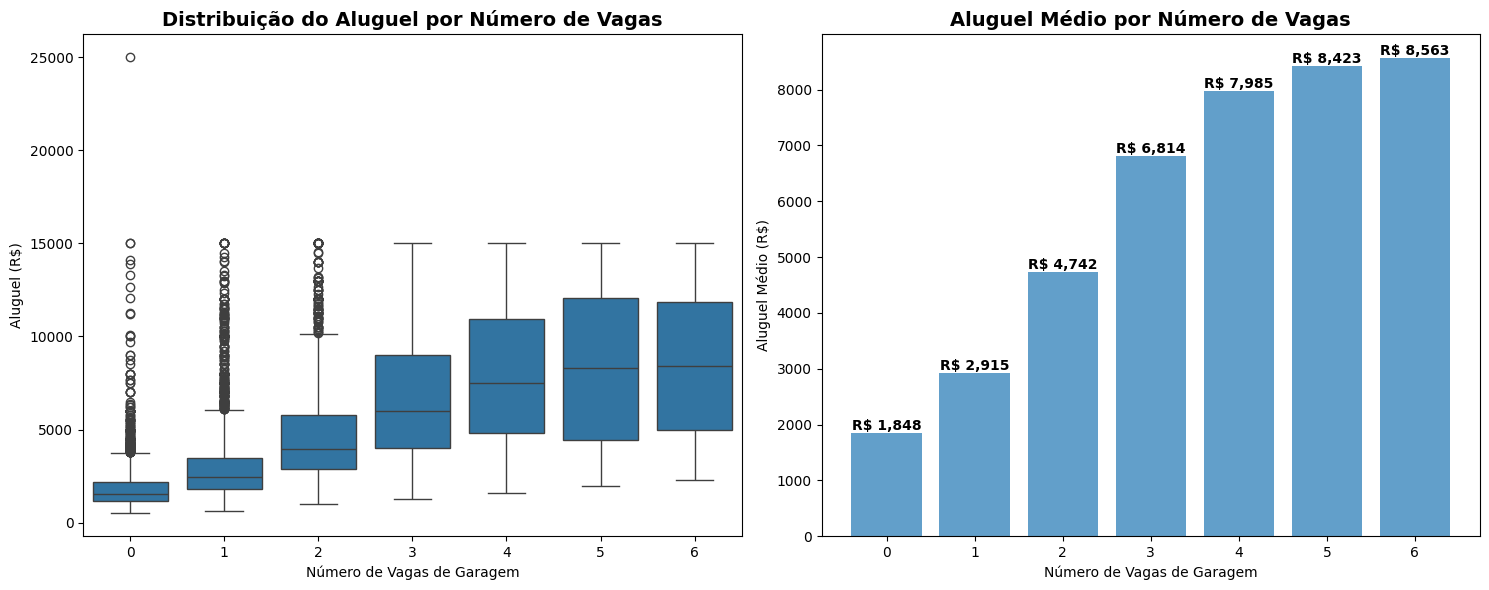

In [73]:
# 🚗 Pergunta 4: Garagem x Valor do Aluguel

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribuição dos aluguéis por número de vagas
sns.boxplot(
    x='garage',
    y='rent',
    data=imoveis,
    ax=ax1
)

ax1.set_title(
    'Distribuição do Aluguel por Número de Vagas',
    fontsize=14,
    fontweight='bold'
)
ax1.set_xlabel('Número de Vagas de Garagem')
ax1.set_ylabel('Aluguel (R$)')

# Gráfico 2: Aluguel médio por número de vagas
aluguel_por_garagem = (
    imoveis.groupby('garage')['rent']
    .mean()
    .sort_index()
)

ax2.bar(
    aluguel_por_garagem.index.astype(str),
    aluguel_por_garagem.values,
    alpha=0.7
)

ax2.set_title(
    'Aluguel Médio por Número de Vagas',
    fontsize=14,
    fontweight='bold'
)
ax2.set_xlabel('Número de Vagas de Garagem')
ax2.set_ylabel('Aluguel Médio (R$)')

# Valores nas barras
for i, valor in enumerate(aluguel_por_garagem.values):
    ax2.text(
        i,
        valor,
        f'R$ {valor:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [74]:
# 📊 Análise estatística

correlacao_garagem = imoveis['garage'].corr(imoveis['rent'])

print("📊 Análise Estatística - Garagem e Aluguel:")
print("=" * 50)

print(f"🚗 Média de vagas: {imoveis['garage'].mean():.2f}")
print(f"💰 Aluguel médio geral: R$ {imoveis['rent'].mean():,.2f}")
print(f"📈 Correlação entre vagas e aluguel: {correlacao_garagem:.3f}")

print("\n💰 Aluguel médio por número de vagas:")

for vagas, valor in aluguel_por_garagem.items():
    quantidade = (imoveis['garage'] == vagas).sum()

    print(
        f"✓ {vagas} vaga(s): "
        f"R$ {valor:,.2f} "
        f"({quantidade} imóveis)"
    )

📊 Análise Estatística - Garagem e Aluguel:
🚗 Média de vagas: 1.06
💰 Aluguel médio geral: R$ 3,250.96
📈 Correlação entre vagas e aluguel: 0.617

💰 Aluguel médio por número de vagas:
✓ 0 vaga(s): R$ 1,847.71 (4118 imóveis)
✓ 1 vaga(s): R$ 2,915.28 (4573 imóveis)
✓ 2 vaga(s): R$ 4,741.68 (1907 imóveis)
✓ 3 vaga(s): R$ 6,813.90 (539 imóveis)
✓ 4 vaga(s): R$ 7,985.17 (321 imóveis)
✓ 5 vaga(s): R$ 8,422.54 (112 imóveis)
✓ 6 vaga(s): R$ 8,563.28 (85 imóveis)


### 🔍 Insights

- 🚗 Existe uma correlação positiva de 0,617 entre o número de vagas de garagem e o valor do aluguel.
- 💰 O aluguel médio aumenta de forma consistente conforme aumenta o número de vagas.
- 🏠 Imóveis sem garagem apresentam aluguel médio de aproximadamente R\$ 1.847.
- 🚗 Imóveis com 2 vagas apresentam aluguel médio de aproximadamente R\$ 4.742.
- 🏢 Imóveis com 4 ou mais vagas apresentam os maiores valores médios de aluguel.
- 📊 A maior parte dos imóveis possui 0 ou 1 vaga, enquanto imóveis com 4, 5 ou 6 vagas são menos frequentes.
- ⚠️ A presença de muitos valores atípicos indica que a quantidade de vagas não explica sozinha o valor do aluguel.
- 🔎 Área, localização e outras características do imóvel também podem estar relacionadas à quantidade de vagas e ao preço.

### 📋 Conclusão

A hipótese é sustentada pelos dados. Existe uma relação positiva moderada entre o número de vagas de garagem e o valor do aluguel, com correlação de 0,617. De modo geral, imóveis com mais vagas apresentam valores de aluguel maiores. Entretanto, essa relação não significa que a garagem, isoladamente, determine o preço, pois imóveis maiores e localizados em regiões mais valorizadas também tendem a possuir mais vagas.

## 🔄 Análise Combinada: Interação entre Variáveis

> **Objetivo:** analisar conjuntamente área, número de quartos, vagas de garagem e tipo de imóvel para compreender quais características estão mais associadas ao valor do aluguel.

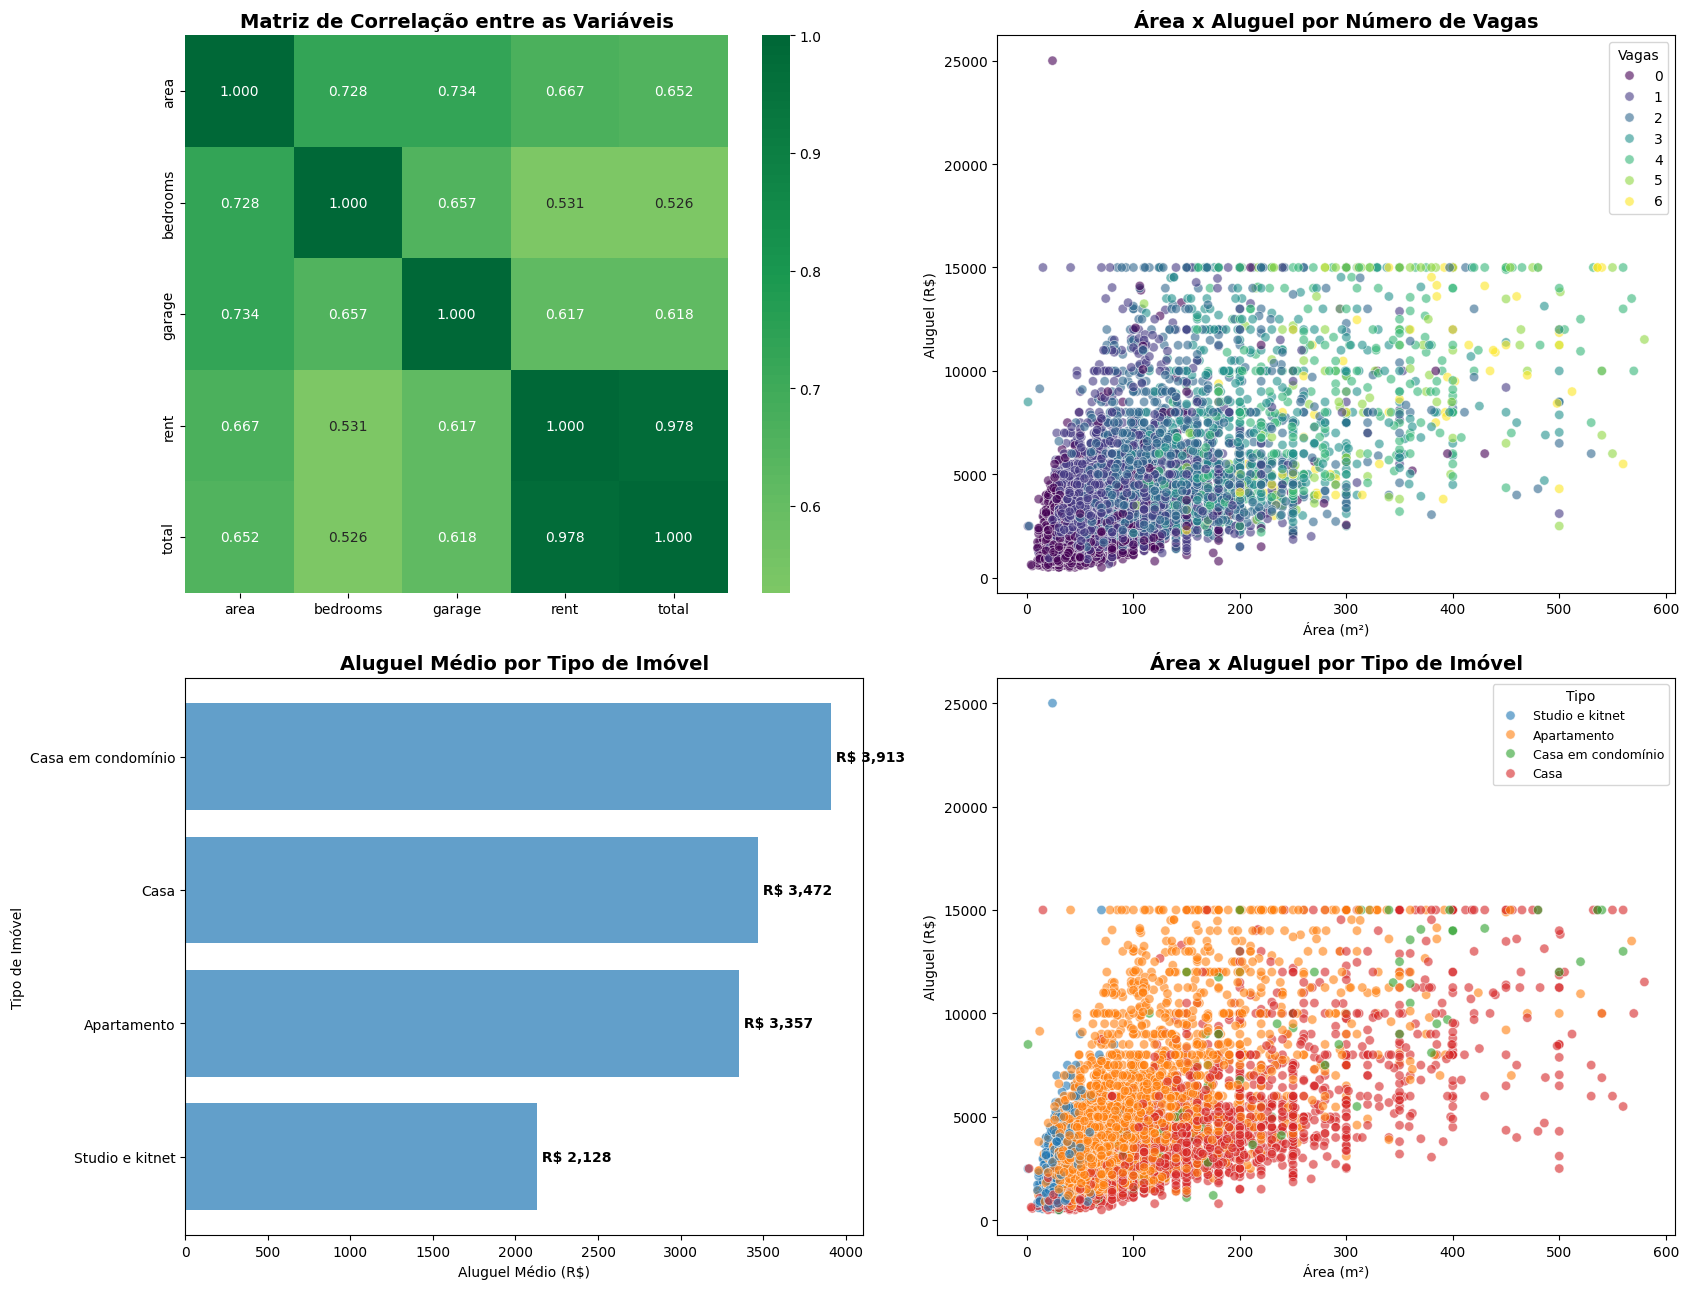

In [75]:
# 🔄 Análise Combinada: Interação entre Variáveis

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2,
    figsize=(17, 13)
)

# Gráfico 1: Matriz de correlação


variaveis_numericas = [
    'area',
    'bedrooms',
    'garage',
    'rent',
    'total'
]

correlacoes = imoveis[variaveis_numericas].corr()

sns.heatmap(
    correlacoes,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    ax=ax1
)

ax1.set_title(
    'Matriz de Correlação entre as Variáveis',
    fontsize=14,
    fontweight='bold'
)



# Gráfico 2: Área x Aluguel, considerando número de vagas


sns.scatterplot(
    data=imoveis,
    x='area',
    y='rent',
    hue='garage',
    palette='viridis',
    alpha=0.6,
    s=45,
    ax=ax2
)

ax2.set_title(
    'Área x Aluguel por Número de Vagas',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel('Área (m²)')
ax2.set_ylabel('Aluguel (R$)')
ax2.legend(title='Vagas')



# Gráfico 3: Aluguel por tipo de imóvel


aluguel_por_tipo = (
    imoveis.groupby('type')['rent']
    .mean()
    .sort_values(ascending=True)
)

ax3.barh(
    aluguel_por_tipo.index,
    aluguel_por_tipo.values,
    alpha=0.7
)

ax3.set_title(
    'Aluguel Médio por Tipo de Imóvel',
    fontsize=14,
    fontweight='bold'
)

ax3.set_xlabel('Aluguel Médio (R$)')
ax3.set_ylabel('Tipo de Imóvel')

for i, valor in enumerate(aluguel_por_tipo.values):
    ax3.text(
        valor,
        i,
        f' R$ {valor:,.0f}',
        va='center',
        fontweight='bold'
    )



# Gráfico 4: Área x Aluguel por tipo de imóvel


sns.scatterplot(
    data=imoveis,
    x='area',
    y='rent',
    hue='type',
    alpha=0.6,
    s=45,
    ax=ax4
)

ax4.set_title(
    'Área x Aluguel por Tipo de Imóvel',
    fontsize=14,
    fontweight='bold'
)

ax4.set_xlabel('Área (m²)')
ax4.set_ylabel('Aluguel (R$)')
ax4.legend(title='Tipo', fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
# 📊 Análise estatística da interação entre variáveis

print("📊 ANÁLISE COMBINADA")
print("=" * 60)

# Correlações com o aluguel
print("\n📈 Correlações com o valor do aluguel:")

correlacoes_aluguel = (
    imoveis[
        ['area', 'bedrooms', 'garage', 'rent']
    ]
    .corr()['rent']
    .drop('rent')
    .sort_values(ascending=False)
)

for variavel, correlacao in correlacoes_aluguel.items():
    print(f"✓ {variavel}: {correlacao:.3f}")


# Aluguel médio por tipo
print("\n🏠 Aluguel médio por tipo de imóvel:")

for tipo, valor in aluguel_por_tipo.sort_values(
    ascending=False
).items():

    quantidade = (imoveis['type'] == tipo).sum()

    print(
        f"✓ {tipo}: R$ {valor:,.2f} "
        f"({quantidade:,} imóveis)"
    )


# Área média por tipo
print("\n📐 Área média por tipo de imóvel:")

area_por_tipo = (
    imoveis.groupby('type')['area']
    .mean()
    .sort_values(ascending=False)
)

for tipo, valor in area_por_tipo.items():
    print(f"✓ {tipo}: {valor:.1f} m²")


# Garagem média por tipo
print("\n🚗 Média de vagas por tipo de imóvel:")

garagem_por_tipo = (
    imoveis.groupby('type')['garage']
    .mean()
    .sort_values(ascending=False)
)

for tipo, valor in garagem_por_tipo.items():
    print(f"✓ {tipo}: {valor:.2f} vagas")

📊 ANÁLISE COMBINADA

📈 Correlações com o valor do aluguel:
✓ area: 0.667
✓ garage: 0.617
✓ bedrooms: 0.531

🏠 Aluguel médio por tipo de imóvel:
✓ Casa em condomínio: R$ 3,912.55 (241 imóveis)
✓ Casa: R$ 3,472.02 (2,840 imóveis)
✓ Apartamento: R$ 3,357.15 (7,193 imóveis)
✓ Studio e kitnet: R$ 2,127.83 (1,381 imóveis)

📐 Área média por tipo de imóvel:
✓ Casa: 136.2 m²
✓ Casa em condomínio: 119.4 m²
✓ Apartamento: 73.3 m²
✓ Studio e kitnet: 31.7 m²

🚗 Média de vagas por tipo de imóvel:
✓ Casa: 1.51 vagas
✓ Casa em condomínio: 1.41 vagas
✓ Apartamento: 1.02 vagas
✓ Studio e kitnet: 0.26 vagas


In [77]:
# 💰 Aluguel por metro quadrado

imoveis['aluguel_m2'] = imoveis['rent'] / imoveis['area']

print("💰 ANÁLISE DO ALUGUEL POR METRO QUADRADO")
print("=" * 55)

print(
    f"Aluguel médio por m²: "
    f"R$ {imoveis['aluguel_m2'].mean():,.2f}"
)

print(
    f"Mediana do aluguel por m²: "
    f"R$ {imoveis['aluguel_m2'].median():,.2f}"
)

print("\n🏠 Aluguel médio por m² segundo o tipo de imóvel:")

aluguel_m2_tipo = (
    imoveis.groupby('type')['aluguel_m2']
    .mean()
    .sort_values(ascending=False)
)

for tipo, valor in aluguel_m2_tipo.items():
    quantidade = (imoveis['type'] == tipo).sum()

    print(
        f"✓ {tipo}: R$ {valor:,.2f}/m² "
        f"({quantidade:,} imóveis)"
    )

💰 ANÁLISE DO ALUGUEL POR METRO QUADRADO
Aluguel médio por m²: R$ 46.69
Mediana do aluguel por m²: R$ 37.50

🏠 Aluguel médio por m² segundo o tipo de imóvel:
✓ Studio e kitnet: R$ 72.74/m² (1,381 imóveis)
✓ Casa em condomínio: R$ 68.29/m² (241 imóveis)
✓ Apartamento: R$ 48.47/m² (7,193 imóveis)
✓ Casa: R$ 27.70/m² (2,840 imóveis)


### 🔍 Insights da Análise Combinada

- 📐 A área apresentou a maior correlação com o valor do aluguel entre as características numéricas analisadas (0,667).
- 🚗 O número de vagas apresentou correlação positiva de 0,617 com o aluguel.
- 🛏️ O número de quartos apresentou correlação positiva de 0,531.
- 🔗 Área, quartos e garagem também apresentam forte associação entre si, indicando que imóveis maiores tendem a possuir mais quartos e vagas.
- 🏠 Casas em condomínio apresentaram o maior aluguel médio (R\$ 3.913), enquanto studios e kitnets apresentaram o menor (R\$ 2.128).
- 📏 As casas apresentaram a maior área média, com 136,2 m², enquanto studios e kitnets apresentaram apenas 31,7 m² em média.
- 💰 Quando analisado o valor por metro quadrado, studios e kitnets apresentaram o maior valor médio, de aproximadamente R$ 72,74/m².
- 🔎 Isso mostra que o imóvel com menor aluguel absoluto não necessariamente é o mais barato proporcionalmente à sua área.
- ⚠️ A quantidade de vagas e quartos está associada à área do imóvel, portanto suas correlações com o aluguel não devem ser interpretadas como efeitos independentes.

### 📋 Conclusão da Análise Combinada

A análise conjunta indica que o valor do aluguel está associado a diversos aspectos do imóvel, sendo a área a característica numérica que apresenta a maior correlação com o preço.

Entretanto, os resultados mostram que não existe um único fator responsável pelo valor do aluguel. Imóveis maiores tendem simultaneamente a possuir mais quartos e vagas, enquanto características como o tipo de imóvel também estão relacionadas ao preço.

A análise do aluguel por metro quadrado revelou ainda uma diferença importante entre os tipos de imóvel. Studios e kitnets apresentam os menores valores de aluguel mensal, mas possuem o maior valor médio por metro quadrado. Já as casas apresentam aluguel total mais elevado, porém menor valor proporcional à área.

Dessa forma, o preço do aluguel parece resultar da combinação entre tamanho, estrutura, tipo de imóvel e localização, e não de uma única característica isolada.

## 💡 Principais Insights

A análise dos dados permitiu identificar os principais fatores associados ao valor dos aluguéis:

1. 📐 **Área do imóvel:** apresentou a maior correlação com o aluguel (0,667), indicando que imóveis maiores tendem a apresentar valores de aluguel mais elevados.

2. 🚗 **Número de vagas:** apresentou correlação de 0,617 com o aluguel. Imóveis com mais vagas tendem a apresentar aluguéis maiores.

3. 🛏️ **Número de quartos:** apresentou correlação de 0,531. Existe uma relação positiva moderada, mas o número de quartos, isoladamente, não explica o preço do imóvel.

4. 🏠 **Tipo de imóvel:** casas em condomínio apresentaram o maior aluguel médio (R\$ 3.913), enquanto studios e kitnets apresentaram o menor (R\$ 2.128).

5. 💰 **Aluguel por m²:** studios e kitnets apresentaram o maior valor médio por metro quadrado (R\$ 72,74/m²), apesar de possuírem o menor aluguel mensal médio.

6. 📍 **Localização:** foram observadas diferenças expressivas entre os bairros, indicando que a região também está associada ao valor dos aluguéis.

7. 🔗 **Interação entre características:** área, número de quartos e vagas apresentam forte associação entre si. Portanto, parte da relação dessas variáveis com o aluguel pode estar relacionada ao tamanho do imóvel.

8. ⚠️ **Valores atípicos:** foram identificados imóveis com valores de aluguel muito superiores aos demais, mostrando que características não analisadas também podem explicar parte da variação dos preços.

In [78]:
# 💡 Resumo dos principais fatores associados ao aluguel

print("💡 PRINCIPAIS FATORES ASSOCIADOS AO ALUGUEL")
print("=" * 60)

# Correlações
correlacoes_principais = (
    imoveis[['area', 'garage', 'bedrooms', 'rent']]
    .corr()['rent']
    .drop('rent')
    .sort_values(ascending=False)
)

print("\n📊 Correlação com o aluguel:")

for variavel, valor in correlacoes_principais.items():
    print(f"✓ {variavel}: {valor:.3f}")

# Tipo de imóvel
print("\n🏠 Aluguel médio por tipo:")

for tipo, valor in aluguel_por_tipo.sort_values(
    ascending=False
).items():
    print(f"✓ {tipo}: R$ {valor:,.2f}")

# Localização
print("\n📍 Bairros com maior aluguel médio:")

bairros_validos = (
    imoveis.groupby('district')
    .agg(
        aluguel_medio=('rent', 'mean'),
        quantidade=('rent', 'count')
    )
)

bairros_validos = bairros_validos[
    bairros_validos['quantidade'] >= 30
]

top_bairros = (
    bairros_validos
    .sort_values('aluguel_medio', ascending=False)
    .head(5)
)

for bairro, dados in top_bairros.iterrows():
    print(
        f"✓ {bairro}: R$ {dados['aluguel_medio']:,.2f} "
        f"({int(dados['quantidade'])} imóveis)"
    )

💡 PRINCIPAIS FATORES ASSOCIADOS AO ALUGUEL

📊 Correlação com o aluguel:
✓ area: 0.667
✓ garage: 0.617
✓ bedrooms: 0.531

🏠 Aluguel médio por tipo:
✓ Casa em condomínio: R$ 3,912.55
✓ Casa: R$ 3,472.02
✓ Apartamento: R$ 3,357.15
✓ Studio e kitnet: R$ 2,127.83

📍 Bairros com maior aluguel médio:
✓ Jardim Leonor: R$ 7,455.74 (38 imóveis)
✓ Tamboré: R$ 6,912.68 (34 imóveis)
✓ Cerqueira César: R$ 6,750.66 (140 imóveis)
✓ Jardim Paulista: R$ 6,305.96 (220 imóveis)
✓ Paraíso: R$ 6,285.56 (89 imóveis)


## 🤖 Regressão Linear: Prevendo o Valor do Aluguel

### 🎯 Objetivo

Nesta etapa, será construído um modelo de regressão linear para estimar o valor do aluguel de um imóvel utilizando sua área, número de quartos e quantidade de vagas de garagem.

O objetivo é verificar até que ponto essas características conseguem explicar e prever o valor do aluguel.

## Modelo 1

In [79]:
# 🤖 Importando as ferramentas para a regressão

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Bibliotecas para regressão carregadas com sucesso!")

✅ Bibliotecas para regressão carregadas com sucesso!


In [80]:
# 📊 Definindo as variáveis do modelo

# Características usadas para tentar prever o aluguel
X = imoveis[['area', 'bedrooms', 'garage']]

# Valor que queremos prever
y = imoveis['rent']

print("📊 Variáveis utilizadas pelo modelo:")
print("✓ Área")
print("✓ Número de quartos")
print("✓ Número de vagas de garagem")

print("\n🎯 Variável que queremos prever:")
print("✓ Valor do aluguel")

📊 Variáveis utilizadas pelo modelo:
✓ Área
✓ Número de quartos
✓ Número de vagas de garagem

🎯 Variável que queremos prever:
✓ Valor do aluguel


In [81]:
# ✂️ Separando os dados em treinamento e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("📚 Dados para treinamento:", len(X_treino))
print("🧪 Dados para teste:", len(X_teste))

📚 Dados para treinamento: 9324
🧪 Dados para teste: 2331


In [82]:
# 🤖 Criando o modelo de regressão linear

modelo = LinearRegression()

print("✅ Modelo de regressão criado!")

✅ Modelo de regressão criado!


In [83]:
# 🧠 Treinando o modelo

modelo.fit(X_treino, y_treino)

print("✅ Modelo treinado com sucesso!")

✅ Modelo treinado com sucesso!


In [84]:
# 📐 Equação encontrada pelo modelo

print("📐 EQUAÇÃO DA REGRESSÃO")

print(f"Intercepto: R$ {modelo.intercept_:,.2f}")

print(f"Coeficiente da área: R$ {modelo.coef_[0]:,.2f}")
print(f"Coeficiente dos quartos: R$ {modelo.coef_[1]:,.2f}")
print(f"Coeficiente da garagem: R$ {modelo.coef_[2]:,.2f}")

print("\n📋 Modelo:")
print(
    f"Aluguel = {modelo.intercept_:.2f} "
    f"+ ({modelo.coef_[0]:.2f} × Área) "
    f"+ ({modelo.coef_[1]:.2f} × Quartos) "
    f"+ ({modelo.coef_[2]:.2f} × Garagem)"
)

📐 EQUAÇÃO DA REGRESSÃO
Intercepto: R$ 1,060.41
Coeficiente da área: R$ 15.71
Coeficiente dos quartos: R$ 97.49
Coeficiente da garagem: R$ 619.76

📋 Modelo:
Aluguel = 1060.41 + (15.71 × Área) + (97.49 × Quartos) + (619.76 × Garagem)


In [85]:
# 🔮 Realizando previsões

y_previsto = modelo.predict(X_teste)

print("🔮 Previsões realizadas com sucesso!")
print(f"Quantidade de imóveis previstos: {len(y_previsto)}")

🔮 Previsões realizadas com sucesso!
Quantidade de imóveis previstos: 2331


In [86]:
# 📊 Comparando valores reais e previstos

resultado_regressao = pd.DataFrame({
    'Aluguel Real': y_teste.values,
    'Aluguel Previsto': y_previsto
})

resultado_regressao['Erro'] = (
    resultado_regressao['Aluguel Real']
    - resultado_regressao['Aluguel Previsto']
)

print("📊 COMPARAÇÃO ENTRE VALORES REAIS E PREVISTOS\n")


display(resultado_regressao.head(10))

📊 COMPARAÇÃO ENTRE VALORES REAIS E PREVISTOS



,Aluguel Real,Aluguel Previsto,Erro
0,1500,1865.003297,-365.003297
1,2850,2959.377082,-109.377082
2,3850,4977.101918,-1127.101918
3,3500,3692.345856,-192.345856
4,2410,2739.391423,-329.391423
5,5000,4478.008923,521.991077
6,1600,1629.304377,-29.304377
7,1350,1852.503728,-502.503728
8,3200,4160.530004,-960.530004
9,2900,2802.244468,97.755532


In [87]:
# 📈 Avaliando o desempenho do modelo

mae = mean_absolute_error(y_teste, y_previsto)

rmse = mean_squared_error(
    y_teste,
    y_previsto
) ** 0.5

r2 = r2_score(
    y_teste,
    y_previsto
)

print("📈 AVALIAÇÃO DO MODELO\n")


print(f"💰 MAE  - Erro médio: R$ {mae:,.2f}")
print(f"📏 RMSE - Erro quadrático médio: R$ {rmse:,.2f}")
print(f"🎯 R²   - Poder explicativo: {r2:.3f}")

📈 AVALIAÇÃO DO MODELO

💰 MAE  - Erro médio: R$ 1,248.27
📏 RMSE - Erro quadrático médio: R$ 1,883.77
🎯 R²   - Poder explicativo: 0.500


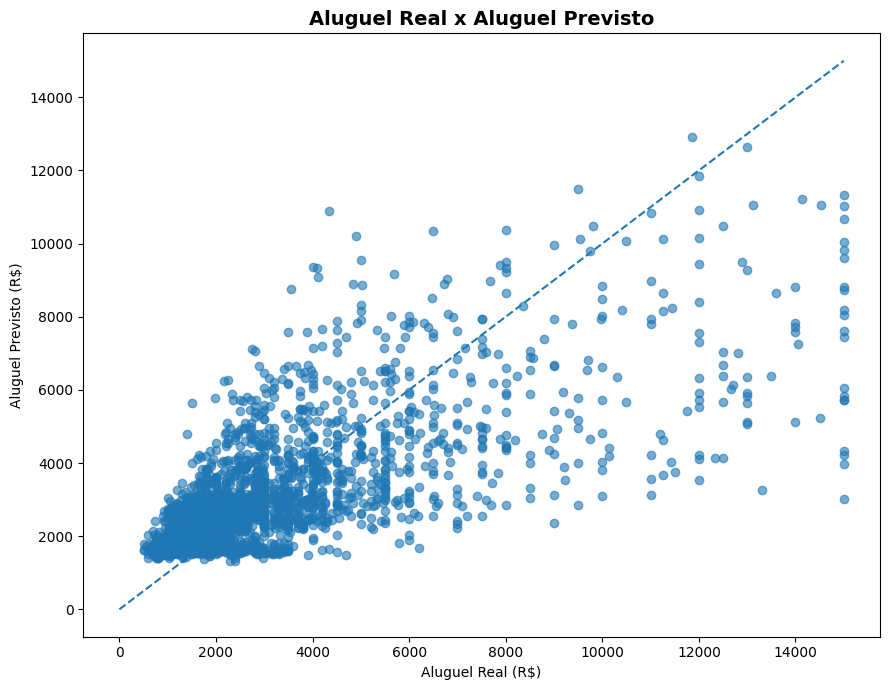

In [88]:
# 📈 Aluguel real x aluguel previsto

plt.figure(figsize=(9, 7))

plt.scatter(
    y_teste,
    y_previsto,
    alpha=0.6
)

# Linha de previsão perfeita
limite = max(y_teste.max(), y_previsto.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle='--'
)

plt.xlabel('Aluguel Real (R$)')
plt.ylabel('Aluguel Previsto (R$)')
plt.title(
    'Aluguel Real x Aluguel Previsto',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Modelo 2

**Melhorando Modelo**

In [89]:
# 🏠 Preparando as variáveis categóricas

# Variáveis numéricas
variaveis_numericas = [
    'area',
    'bedrooms',
    'garage'
]

# Variáveis categóricas
variaveis_categoricas = [
    'type',
    'district'
]

print("📊 Variáveis numéricas:")
for variavel in variaveis_numericas:
    print(f"✓ {variavel}")

print("\n🏠 Variáveis categóricas:")
for variavel in variaveis_categoricas:
    print(f"✓ {variavel}")

📊 Variáveis numéricas:
✓ area
✓ bedrooms
✓ garage

🏠 Variáveis categóricas:
✓ type
✓ district


In [90]:
# 🔢 Transformando variáveis categóricas em números

imoveis_modelo = pd.get_dummies(
    imoveis[
        variaveis_numericas +
        variaveis_categoricas +
        ['rent']
    ],
    columns=variaveis_categoricas,
    drop_first=True
)

print("✅ Variáveis categóricas transformadas!")

print(f"\n📏 Dimensões do novo conjunto: {imoveis_modelo.shape}")

print("\n📋 Primeiras colunas:")
print(list(imoveis_modelo.columns)[:20])

✅ Variáveis categóricas transformadas!

📏 Dimensões do novo conjunto: (11655, 1205)

📋 Primeiras colunas:
['area', 'bedrooms', 'garage', 'rent', 'type_Casa', 'type_Casa em condomínio', 'type_Studio e kitnet', 'district_Adalgisa', 'district_Agua Branca', 'district_Alphaville', 'district_Alphaville Centro Industrial E Empresarial/alphaville.', 'district_Alphaville Conde Ii', 'district_Alphaville Empresarial', 'district_Alphaville Industrial', 'district_Alphaville Residencial Dois', 'district_Alphaville Residencial Plus', 'district_Alphaville Residencial Um', 'district_Alto da Boa Vista', 'district_Alto da Lapa', 'district_Alto da Mooca']


In [91]:
# 📊 Separando variáveis explicativas e variável alvo

X2 = imoveis_modelo.drop('rent', axis=1)
y2 = imoveis_modelo['rent']

print(f"📊 Quantidade de variáveis utilizadas: {X2.shape[1]}")
print(f"🎯 Total de imóveis: {len(y2)}")

📊 Quantidade de variáveis utilizadas: 1204
🎯 Total de imóveis: 11655


In [92]:
# ✂️ Separando os dados do segundo modelo

X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

print("📚 Dados de treinamento:", len(X2_treino))
print("🧪 Dados de teste:", len(X2_teste))

📚 Dados de treinamento: 9324
🧪 Dados de teste: 2331


In [93]:
# 🤖 Criando e treinando o segundo modelo

modelo2 = LinearRegression()

modelo2.fit(
    X2_treino,
    y2_treino
)

print("✅ Segundo modelo treinado com sucesso!")

✅ Segundo modelo treinado com sucesso!


In [94]:
# 🔮 Previsões do segundo modelo

y2_previsto = modelo2.predict(X2_teste)

print("🔮 Previsões realizadas!")
print(f"Quantidade de imóveis previstos: {len(y2_previsto)}")

🔮 Previsões realizadas!
Quantidade de imóveis previstos: 2331


In [95]:
# 📊 Avaliação do segundo modelo

mae2 = mean_absolute_error(
    y2_teste,
    y2_previsto
)

rmse2 = mean_squared_error(
    y2_teste,
    y2_previsto
) ** 0.5

r22 = r2_score(
    y2_teste,
    y2_previsto
)

print("📊 AVALIAÇÃO DO MODELO 2")
print("=" * 55)

print(f"💰 MAE  : R$ {mae2:,.2f}")
print(f"📏 RMSE : R$ {rmse2:,.2f}")
print(f"🎯 R²   : {r22:.3f}")

📊 AVALIAÇÃO DO MODELO 2
💰 MAE  : R$ 1,005.91
📏 RMSE : R$ 1,537.59
🎯 R²   : 0.667


## 📊 Comparação entre os Modelos

Foram construídos dois modelos de regressão linear para estimar o valor do aluguel.

### Modelo 1
Utilizou apenas características físicas do imóvel:

- Área
- Número de quartos
- Número de vagas de garagem

### Modelo 2
Além das características físicas, foram adicionadas:

- Tipo de imóvel
- Bairro

### Resultados

| Métrica | Modelo 1 | Modelo 2 |
|---|---:|---:|
| MAE | R\$ 1.248,27 | R\$ 1.005,91 |
| RMSE | R\$ 1.883,77 | R\$ 1.537,59 |
| R² | 0,500 | 0,667 |

### 🔍 Interpretação

A inclusão do tipo de imóvel e da localização melhorou o desempenho do modelo.

O R² aumentou de 0,500 para 0,667, indicando que o segundo modelo consegue explicar uma parcela maior da variação observada nos valores de aluguel.

Além disso, o MAE diminuiu de R\$ 1.248,27 para R\$ 1.005,91, mostrando uma redução no erro médio das previsões.

Os resultados reforçam os insights obtidos durante a análise exploratória: características físicas são importantes para determinar o aluguel, mas fatores relacionados à localização e ao tipo de imóvel também possuem forte influência sobre o preço.

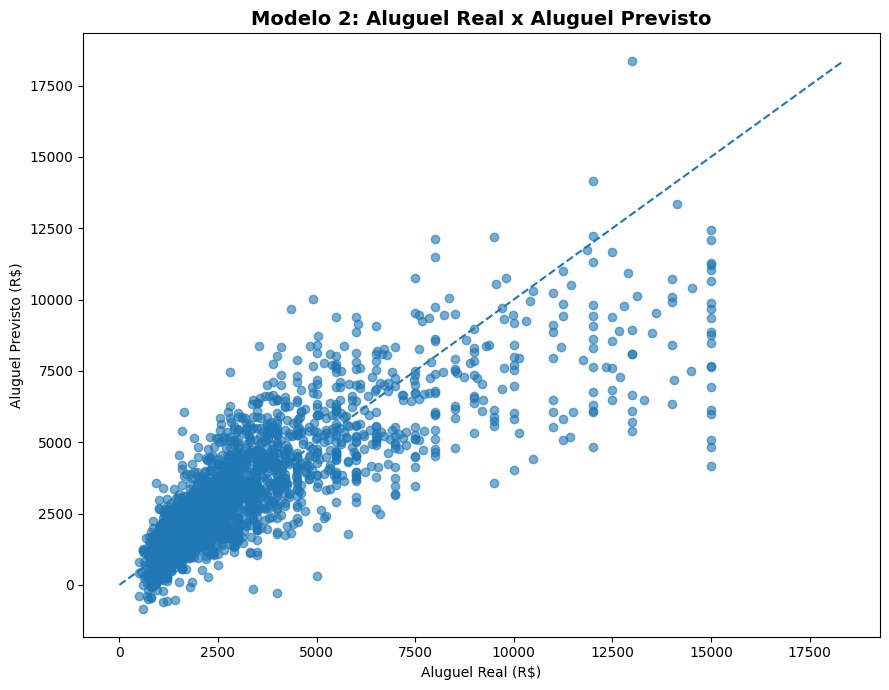

In [96]:
# 📈 Aluguel real x aluguel previsto - Modelo 2

plt.figure(figsize=(9, 7))

plt.scatter(
    y2_teste,
    y2_previsto,
    alpha=0.6
)

# Linha de previsão perfeita
limite = max(y2_teste.max(), y2_previsto.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle='--'
)

plt.xlabel('Aluguel Real (R$)')
plt.ylabel('Aluguel Previsto (R$)')
plt.title(
    'Modelo 2: Aluguel Real x Aluguel Previsto',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

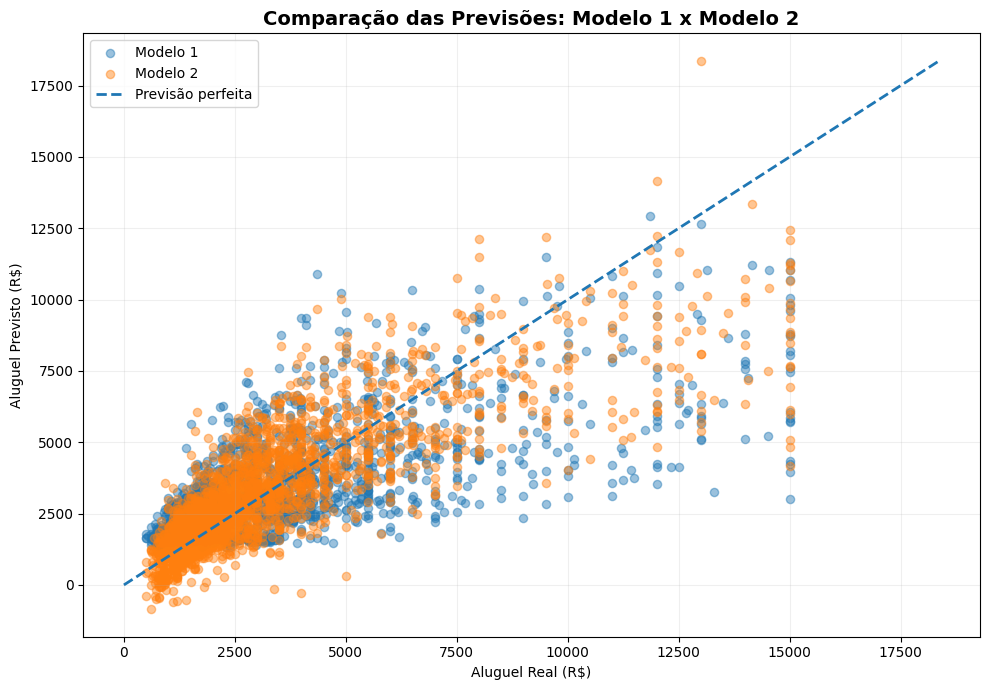

In [97]:
# 📊 Comparação dos dois modelos - gráfico de dispersão

plt.figure(figsize=(10, 7))

# Modelo 1
plt.scatter(
    y_teste,
    y_previsto,
    alpha=0.45,
    s=35,
    label='Modelo 1'
)

# Modelo 2
plt.scatter(
    y2_teste,
    y2_previsto,
    alpha=0.45,
    s=35,
    label='Modelo 2'
)

# Linha de previsão perfeita
limite = max(
    y_teste.max(),
    y_previsto.max(),
    y2_teste.max(),
    y2_previsto.max()
)

plt.plot(
    [0, limite],
    [0, limite],
    linestyle='--',
    linewidth=2,
    label='Previsão perfeita'
)

plt.xlabel('Aluguel Real (R$)')
plt.ylabel('Aluguel Previsto (R$)')

plt.title(
    'Comparação das Previsões: Modelo 1 x Modelo 2',
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [98]:
# 🏠 Simulação de um imóvel

imovel_exemplo = pd.DataFrame({
    'area': [80],
    'bedrooms': [2],
    'garage': [1],
    'type': ['Apartamento'],
    'district': ['Bela Vista']
})

print("🏠 IMÓVEL PARA SIMULAÇÃO")
print("=" * 40)

print(f"Tipo: {imovel_exemplo['type'].iloc[0]}")
print(f"Bairro: {imovel_exemplo['district'].iloc[0]}")
print(f"Área: {imovel_exemplo['area'].iloc[0]} m²")
print(f"Quartos: {imovel_exemplo['bedrooms'].iloc[0]}")
print(f"Garagem: {imovel_exemplo['garage'].iloc[0]}")

🏠 IMÓVEL PARA SIMULAÇÃO
Tipo: Apartamento
Bairro: Bela Vista
Área: 80 m²
Quartos: 2
Garagem: 1


In [99]:
# 🔢 Preparando o imóvel para o modelo

imovel_codificado = pd.get_dummies(
    imovel_exemplo,
    columns=['type', 'district'],
    drop_first=True
)

# Garantindo que o imóvel tenha exatamente as mesmas colunas
# utilizadas durante o treinamento
imovel_codificado = imovel_codificado.reindex(
    columns=X2.columns,
    fill_value=0
)

print("✅ Imóvel preparado para a previsão!")
print(f"Quantidade de variáveis: {imovel_codificado.shape[1]}")

✅ Imóvel preparado para a previsão!
Quantidade de variáveis: 1204


## 🤖 Aplicação Prática da Regressão

O segundo modelo apresentou desempenho superior ao primeiro modelo, após a inclusão das variáveis de tipo de imóvel e localização.

O modelo alcançou um R² de 0,667 e um MAE de R$ 1.005,91, indicando que essas características contribuem significativamente para a estimativa dos valores de aluguel.

Como aplicação prática, o modelo também foi utilizado para estimar o aluguel de um imóvel hipotético a partir de suas características, demonstrando como técnicas de regressão linear podem ser utilizadas para apoiar análises e estimativas no mercado imobiliário.

É importante destacar que a previsão representa uma estimativa estatística e não deve ser interpretada como uma determinação exata do preço de mercado. Outros fatores não presentes no conjunto de dados também podem influenciar o valor do aluguel.

In [100]:
# 🔮 Estimativa de aluguel usando o Modelo 2

previsao = modelo2.predict(imovel_codificado)[0]

print("🏠 ESTIMATIVA DE ALUGUEL - MODELO 2\n")


print(f"📍 Bairro: {imovel_exemplo['district'].iloc[0]}")
print(f"🏢 Tipo: {imovel_exemplo['type'].iloc[0]}")
print(f"📐 Área: {imovel_exemplo['area'].iloc[0]} m²")
print(f"🛏️ Quartos: {imovel_exemplo['bedrooms'].iloc[0]}")
print(f"🚗 Garagem: {imovel_exemplo['garage'].iloc[0]} vaga(s)")

print(f"\n💰 Aluguel estimado: R$ {previsao:,.2f}")

🏠 ESTIMATIVA DE ALUGUEL - MODELO 2

📍 Bairro: Bela Vista
🏢 Tipo: Apartamento
📐 Área: 80 m²
🛏️ Quartos: 2
🚗 Garagem: 1 vaga(s)

💰 Aluguel estimado: R$ 3,103.06


## 🔮 Aplicação Prática do Modelo

Para demonstrar uma aplicação prática da regressão, foi utilizado o Modelo 2 para estimar o valor de aluguel de um imóvel hipotético.

O imóvel possui 80 m², 2 quartos e 1 vaga de garagem, é classificado como apartamento e está localizado no bairro Bela Vista.

Com essas características, o modelo estimou um aluguel de:

**R$ 3.103,06**

Essa estimativa demonstra como o modelo pode ser utilizado para obter uma referência de preço a partir das características de um imóvel.

É importante destacar que a previsão é uma estimativa estatística e pode apresentar diferenças em relação ao preço real de mercado, pois outros fatores não presentes no dataset também podem influenciar o valor do aluguel.

## 🏆 Conclusões e Recomendações

### 📋 Conclusões

A análise de **11.655 imóveis** permitiu identificar diferentes características associadas ao valor dos aluguéis.

A **área** foi a variável numérica com maior correlação com o aluguel (**0,667**), seguida pelo número de **vagas de garagem (0,617)** e pelo número de **quartos (0,531)**. Esses resultados indicam que imóveis maiores e com maior estrutura tendem a apresentar valores de aluguel mais elevados.

Entretanto, a análise combinada mostrou que essas características não são independentes. Área, quartos e vagas apresentam forte associação entre si. Portanto, não é possível afirmar que uma dessas características, isoladamente, seja responsável pelo aumento do aluguel.

O **tipo de imóvel** também apresentou diferenças importantes. Casas em condomínio tiveram o maior aluguel médio, enquanto studios e kitnets apresentaram o menor aluguel mensal. Quando analisado o valor por metro quadrado, entretanto, os studios e kitnets apresentaram o maior preço proporcional à área.

A **localização** também demonstrou grande variação nos preços médios entre os bairros, reforçando a importância da região na formação do valor do aluguel.

### 🤖 Regressão Linear

A análise exploratória foi complementada pela construção de modelos de regressão linear para estimar o valor dos aluguéis.

O primeiro modelo utilizou características estruturais do imóvel, como área, número de quartos e vagas de garagem. O segundo modelo incorporou também o **tipo de imóvel e a localização**, apresentando desempenho superior.

| Métrica | Modelo 1 | Modelo 2 |
|---|---:|---:|
| MAE | R\$ 1.248,27 | **R\$ 1.005,91** |
| RMSE | R\$ 1.883,77 | **R\$ 1.537,59** |
| R² | 0,500 | **0,667** |

O Modelo 2 apresentou uma melhora significativa. O R² passou de **0,500** para **0,667**, enquanto o erro médio absoluto diminuiu de **R\$ 1.248,27** para **R\$ 1.005,91**.

Isso indica que a inclusão de informações relacionadas ao **tipo de imóvel e à localização** contribuiu para melhorar a capacidade do modelo de explicar e estimar os valores dos aluguéis.

Como aplicação prática, o Modelo 2 foi utilizado para estimar o aluguel de um imóvel hipotético de **80 m², 2 quartos, 1 vaga, do tipo apartamento, localizado no bairro Bela Vista**. A estimativa obtida foi de **R$ 3.103,06**.

A regressão, portanto, demonstrou que os dados podem ser utilizados não apenas para identificar padrões, mas também para construir uma ferramenta de estimativa de preços.

### 💡 Recomendações

- 🏠 **Para quem procura um imóvel:** comparar apenas o valor mensal pode ser insuficiente. O preço por metro quadrado pode ajudar a identificar imóveis relativamente mais caros ou mais baratos.

- 📐 **Para proprietários:** características como área, número de quartos, vagas, tipo de imóvel e localização devem ser consideradas conjuntamente ao estabelecer o preço.

- 📍 **Para análise de mercado:** a localização deve ser considerada, pois bairros diferentes apresentam valores médios bastante distintos.

- 💰 **Para comparação de imóveis:** recomenda-se analisar tanto o aluguel total quanto o aluguel por metro quadrado.

- 🤖 **Para estimativa de preços:** modelos de regressão podem auxiliar na definição de uma faixa de preço, utilizando características observáveis do imóvel.

- ⚠️ **Para tomada de decisão:** a previsão do modelo deve ser utilizada como referência, e não como valor exato de mercado, pois existem fatores relevantes que não estão presentes no dataset.

## 🎓 Resumo Final

### 🏠 O que determina o valor dos aluguéis?

A análise dos dados mostrou que:

1. 📐 **Área** foi a variável numérica mais associada ao aluguel — correlação de **0,667**.
2. 🚗 **Garagem** apresentou correlação de **0,617**.
3. 🛏️ **Quartos** apresentaram correlação de **0,531**.
4. 🏠 **Casas em condomínio** apresentaram o maior aluguel médio.
5. 💰 **Studios e kitnets** apresentaram o maior aluguel médio por m².
6. 📍 **Localização** apresentou diferenças expressivas entre os bairros.
7. 🔗 **As características dos imóveis estão relacionadas entre si**, especialmente área, quartos e garagem.
8. 🤖 **O Modelo 2 apresentou melhor desempenho**, alcançando R² de **0,667** e MAE de **R\$ 1.005,91**.
9. 🏠 **O modelo foi capaz de estimar o aluguel de um imóvel hipotético**, produzindo uma estimativa de **R\$ 3.103,06**.
10. ⚠️ **Nenhuma variável isolada explica completamente o preço do aluguel.**

### 🔎 Principal conclusão

> **O valor do aluguel resulta da combinação entre tamanho, estrutura, tipo de imóvel e localização. A regressão linear mostrou que essas informações podem ser utilizadas não apenas para compreender os padrões do mercado, mas também para produzir estimativas de preço.**